In [1]:
# ============================================================
# COACH — Session Start  (do not remove this cell)
# ============================================================
import sys, os
sys.path.insert(0, os.path.expanduser('~/Desktop/applied-ai-research'))
from coach.notebook_widgets import render_session_start
_SESSION = render_session_start(
    module_id="transformers",
    notebook_name="01_attention_mechanisms.ipynb"
)

# Attention Mechanisms: The Heart of Transformers

## The Mystery Worth Solving

Here's something that should make you curious: every time you chat with a language model, it's doing something remarkable. It is not reading words one at a time. It is looking at every word in your message *simultaneously* and for each word, deciding how much every other word matters for understanding it.

One sentence. Every word. Looking at every other word. At the same time.

That's attention. And by the end of this notebook, you will have built it yourself.

---

In this notebook, we'll build attention from scratch using only NumPy. By the end, you'll:

1. Understand **why** attention was invented
2. Implement **scaled dot-product attention** step by step
3. **Visualize** attention weights to see what the model "looks at"
4. Understand the difference between **self-attention** and **cross-attention**

**Prerequisites:** Basic Python, NumPy, and neural network fundamentals from `00-neural-networks`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# For nicer plots
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 12

np.random.seed(42)  # For reproducibility
print("Setup complete!")

Setup complete!


## Part 1: Why Do We Need Attention?

### Layer 1: The Whisper Chain Problem

Imagine playing the telephone game (whisper chain) with 50 people. You whisper "The cat is tired" to person 1. By the time the message reaches person 50, it's been distorted through 49 transformations. Person 50 barely remembers what the original message said.

That's what happened to RNNs. Each step was like one person whispering to the next:

```
"The" → "cat" → "sat" → "on" → "the" → "mat" → "because" → "it" → "was" → "tired"
  ↓        ↓        ↓       ↓       ↓        ↓         ↓         ↓       ↓       ↓
 h₁  →   h₂   →   h₃  →  h₄  →  h₅   →   h₆   →   h₇   →   h₈  →  h₉  →  h₁₀
```

By the time the model reaches "it", the memory of "cat" has traveled through 7 transformations. The gradient (the learning signal) shrinks by a factor at each step. After 50 steps, it's virtually zero. The network can't learn long-range connections.

**Attention skips the chain entirely.** Every word can directly look at every other word, regardless of distance.

**Where this analogy breaks down:** In a telephone game, each person passes information only to the next person -- there is one fixed path. In attention, every word sends information directly to every other word at the same time -- there are n-squared paths simultaneously. Also, telephone errors are random and unpredictable. RNN errors accumulate deterministically through the weight matrix, which is why the fix requires controlling the spectral radius, not just adding more people to the chain.

### Layer 2: The Vanishing Gradient Math

In an RNN, the gradient at time step t depends on gradients at time t+1 through t+k:

```
∂L/∂h_t = (∂L/∂h_{t+k}) × ∏_{i=t}^{t+k-1} (∂h_{i+1}/∂h_i)
```

Each term ∂h_{i+1}/∂h_i = diag(σ'(h_i)) × W_rec (the recurrent weight matrix). The spectral radius of W_rec determines whether gradients vanish (< 1) or explode (> 1). For vanilla RNNs processing sequences longer than ~10-20 steps, gradients reliably vanish.

In attention, gradients flow directly from any output position to any input position through the attention weights — no chain multiplication. The gradient path length is always O(1), not O(n). This is the core computational advantage.

## Part 2: Word Embeddings (Words → Numbers)

Before we can do attention, we need to convert words into numbers. Each word becomes a **vector** (a list of numbers) called an **embedding**.

In real models, these embeddings are learned from data and have hundreds of dimensions. For learning, we'll use tiny 4-dimensional embeddings.

In [3]:
# Our sentence: "The cat sat"
# In real models, embeddings come from a learned lookup table.
# Here we'll use small, hand-crafted ones so we can see what's happening.

words = ["The", "cat", "sat"]
d_model = 4  # Embedding dimension (real models use 512, 768, etc.)

# Each word is represented as a vector of d_model numbers
embeddings = {
    "The": np.array([1.0, 0.0, 0.0, 0.1]),   # Articles
    "cat": np.array([0.0, 1.0, 0.8, 0.0]),    # Nouns/animals
    "sat": np.array([0.0, 0.5, 0.0, 1.0]),    # Verbs/actions
}

# Stack into a matrix: each ROW is one word's embedding
X = np.array([embeddings[w] for w in words])

print("Input matrix X (each row = one word):")
print(f"Shape: {X.shape}  (3 words × 4 dimensions)")
print()
for i, word in enumerate(words):
    print(f"  '{word}': {X[i]}")

Input matrix X (each row = one word):
Shape: (3, 4)  (3 words × 4 dimensions)

  'The': [1.  0.  0.  0.1]
  'cat': [0.  1.  0.8 0. ]
  'sat': [0.  0.5 0.  1. ]


## Part 3: Creating Q, K, V (Query, Key, Value)

### Layer 1: The Library Analogy (Revisited)

Think of searching a library:

| Role | Library Version | In Attention |
|------|----------------|-------------|
| **Query (Q)** | Your question: "I want books about dinosaurs" | What this word is *looking for* |
| **Key (K)** | Label on each shelf: "Science", "History" | What each word *advertises* about itself |
| **Value (V)** | The actual books on each shelf | The actual information each word carries |

You compare your question (Q) to each shelf label (K). The better the match, the more books (V) you take from that shelf. The final "answer" is a weighted mix of books from all shelves.

**Important:** In self-attention, every word plays ALL THREE roles simultaneously:
- "cat" has its own Query (what it's looking for)
- "cat" has its own Key (what it tells others about itself)
- "cat" has its own Value (what information it shares when others attend to it)

**What this analogy gets right:** You look at every shelf label (Key), and your final answer is a weighted blend of books from multiple shelves (Values) -- not just the best match. That is exactly how attention works: the output is always a weighted sum over all positions, not a winner-takes-all selection.

**Where this analogy breaks down:** In a library, shelf labels and books were created by someone else. In attention, every word creates its own Key and Value by multiplying its embedding by learned weight matrices W_K and W_V. The word simultaneously labels itself for others to find and decides what content it carries. Real library books do not generate their own labels.

### Layer 2: The Linear Projection

Each of Q, K, V is a learned linear projection of the input embedding:

```
Q = X × W_Q    where W_Q ∈ R^{d_model × d_k}
K = X × W_K    where W_K ∈ R^{d_model × d_k}
V = X × W_V    where W_V ∈ R^{d_model × d_v}
```

Why separate matrices instead of one? W_Q learns to extract "question-asking" features from a word. W_K learns to extract "label-advertising" features. W_V learns to extract "content-sharing" features. The same word can produce very different Q and K projections — a verb's Query might point toward subjects, while its Key points toward objects. This specialization is learned entirely from data.

Parameter count for Q, K, V projections: 3 × d_model × d_k. For d_model = 512, d_k = 64: 3 × 512 × 64 = 98,304 parameters per head (before the output projection).

In [4]:
# In real transformers, these weight matrices are LEARNED during training.
# Here we initialize them randomly to demonstrate the concept.

d_k = 3  # Dimension of queries and keys (can differ from d_model)
d_v = 3  # Dimension of values

# Weight matrices (these would be learned in a real model)
W_Q = np.random.randn(d_model, d_k) * 0.5  # Shape: (4, 3)
W_K = np.random.randn(d_model, d_k) * 0.5  # Shape: (4, 3)
W_V = np.random.randn(d_model, d_v) * 0.5  # Shape: (4, 3)

print("Weight matrices (learned during training):")
print(f"  W_Q shape: {W_Q.shape}  (d_model × d_k = {d_model} × {d_k})")
print(f"  W_K shape: {W_K.shape}  (d_model × d_k = {d_model} × {d_k})")
print(f"  W_V shape: {W_V.shape}  (d_model × d_v = {d_model} × {d_v})")

Weight matrices (learned during training):
  W_Q shape: (4, 3)  (d_model × d_k = 4 × 3)
  W_K shape: (4, 3)  (d_model × d_k = 4 × 3)
  W_V shape: (4, 3)  (d_model × d_v = 4 × 3)


In [5]:
# Create Q, K, V by multiplying embeddings by weight matrices
Q = X @ W_Q  # (3 words × 4 dims) @ (4 dims × 3 d_k) = (3 words × 3 d_k)
K = X @ W_K  # Same shape
V = X @ W_V  # Same shape

print("Q (Queries - what each word is looking for):")
for i, word in enumerate(words):
    print(f"  Q_{word}: {np.round(Q[i], 3)}")

print(f"\nK (Keys - what each word advertises):")
for i, word in enumerate(words):
    print(f"  K_{word}: {np.round(K[i], 3)}")

print(f"\nV (Values - actual information each word carries):")
for i, word in enumerate(words):
    print(f"  V_{word}: {np.round(V[i], 3)}")

Q (Queries - what each word is looking for):
  Q_The: [ 0.275 -0.092  0.301]
  Q_cat: [ 1.393  0.19  -0.305]
  Q_sat: [ 0.652 -0.29  -0.291]

K (Keys - what each word advertises):
  K_The: [ 0.11  -0.953 -0.934]
  K_cat: [-0.644 -1.071  0.743]
  K_sat: [-0.253 -0.219 -0.634]

V (Values - actual information each word carries):
  V_The: [-0.325  0.097 -0.637]
  V_cat: [-0.053  0.441 -0.151]
  V_sat: [-0.435  0.261 -0.683]


## Part 4: Computing Attention Scores (Q × K^T)

Now we measure how well each Query matches each Key using the **dot product**.

### What's a Dot Product?

The dot product measures how similar two vectors point in the same direction:
- **High positive** = very similar
- **Near zero** = unrelated
- **Negative** = opposite

```
Example:
  [1, 0, 1] · [1, 0, 1] = 1×1 + 0×0 + 1×1 = 2   (SAME direction → high!)
  [1, 0, 1] · [0, 1, 0] = 1×0 + 0×1 + 1×0 = 0   (perpendicular → zero!)
```

In [6]:
# Compute attention scores: Q × K^T
# This gives us a score for every (query word, key word) pair

scores = Q @ K.T  # (3 words × 3 d_k) @ (3 d_k × 3 words) = (3 × 3)

print("Attention scores (Q × K^T):")
print(f"Shape: {scores.shape}  (every word scored against every other word)\n")

# Display as a nice table
print(f"{'':>8}", end="")
for word in words:
    print(f"{word:>10}", end="")
print("  ← Keys")
print(f"{'':>8}" + "-" * 30)
for i, word in enumerate(words):
    print(f"{word:>6} |", end="")
    for j in range(len(words)):
        print(f"{scores[i, j]:>10.3f}", end="")
    print()
print(f"{'':>8}↑ Queries")
print(f"\nEach cell = how much the row word's Query matches the column word's Key")

Attention scores (Q × K^T):
Shape: (3, 3)  (every word scored against every other word)

               The       cat       sat  ← Keys
        ------------------------------
   The |    -0.162     0.145    -0.240
   cat |     0.256    -1.328    -0.202
   sat |     0.620    -0.326     0.083
        ↑ Queries

Each cell = how much the row word's Query matches the column word's Key


## Part 5: Scaling (÷ √d_k)

### Layer 1: Why You Need to Scale Down

Imagine rolling two dice and multiplying the results. With 1 die, scores range from 1–6. With 100 dice, the total ranges from 100–600 — the numbers get big just because you're adding more terms.

The same thing happens with dot products. When vectors have d_k dimensions, the dot product is the sum of d_k multiplied pairs. As d_k grows, dot products naturally get bigger.

Big dot products → softmax becomes a "winner-take-all" spike → model attends to only one word → can't blend information → training breaks.

Dividing by sqrt(d_k) fixes this by keeping scores in a reasonable range.

**What this analogy gets right:** More dice = larger totals, just as more dimensions = larger dot products. Scaling down keeps scores in a reasonable range.

**Where this analogy breaks down:** Dice outcomes are uniformly distributed from 1 to 6. Query and key vector entries are normally distributed and centered at 0. The specific divisor sqrt(d_k) -- not d_k or some other constant -- comes from the variance of the normal distribution, not the range of dice. The dice analogy gives you the motivation but not the derivation.

### Layer 2: The Variance Proof

Fair warning: this is the most mathematical section in the notebook. The key insight to hold onto is the conclusion -- unit variance -- and why that matters for softmax gradients. You do not need to reproduce this derivation from memory.

Assume Q and K have i.i.d. entries sampled from N(0, 1) (standard normal — mean 0, variance 1). This is approximately true after LayerNorm.

The dot product Q·K = Σᵢ qᵢkᵢ is a sum of d_k independent terms.

Each term qᵢkᵢ has:
- E[qᵢkᵢ] = E[qᵢ] × E[kᵢ] = 0 (independent, both mean 0)
- Var[qᵢkᵢ] = E[qᵢ²kᵢ²] = E[qᵢ²] × E[kᵢ²] = 1 × 1 = 1

Sum of d_k independent terms, each with variance 1:
- Var[Q·K] = d_k × 1 = d_k
- StdDev[Q·K] = √d_k

Dividing by √d_k: Var[(Q·K)/√d_k] = d_k / d_k = 1.

So dividing by √d_k normalizes the dot product back to unit variance — the same distribution as each individual entry. Softmax works best when inputs have variance ~1; much larger inputs push it into saturation.

**Saturation means near-zero gradients:** softmax(x)_i ≈ 1 for the max element and ≈ 0 for others. The gradient ∂softmax(x)_i/∂x_j = softmax(x)_i(δᵢⱼ - softmax(x)_j) → 0 everywhere. Training stops.

In [7]:
# Scale by sqrt(d_k)
scale = np.sqrt(d_k)
scaled_scores = scores / scale

print(f"Scaling factor: √d_k = √{d_k} = {scale:.3f}")
print(f"\nBefore scaling: scores range from {scores.min():.3f} to {scores.max():.3f}")
print(f"After scaling:  scores range from {scaled_scores.min():.3f} to {scaled_scores.max():.3f}")
print("\nScaled scores:")
print(np.round(scaled_scores, 3))

# Demonstrate why scaling matters
print("\n--- Why scaling matters ---")
large_scores = np.array([100.0, 1.0, 2.0])
small_scores = np.array([3.0, 1.0, 2.0])

def softmax(x):
    exp_x = np.exp(x - np.max(x))  # Subtract max for numerical stability
    return exp_x / exp_x.sum()

print(f"Unscaled scores {large_scores} → softmax: {np.round(softmax(large_scores), 6)}")
print(f"  → Almost ALL weight on first element! Can't blend information.")
print(f"Scaled scores   {small_scores} → softmax: {np.round(softmax(small_scores), 4)}")
print(f"  → Weights are spread out. Model can blend from multiple words.")

Scaling factor: √d_k = √3 = 1.732

Before scaling: scores range from -1.328 to 0.620
After scaling:  scores range from -0.767 to 0.358

Scaled scores:
[[-0.094  0.084 -0.139]
 [ 0.148 -0.767 -0.116]
 [ 0.358 -0.188  0.048]]

--- Why scaling matters ---
Unscaled scores [100.   1.   2.] → softmax: [1. 0. 0.]
  → Almost ALL weight on first element! Can't blend information.
Scaled scores   [3. 1. 2.] → softmax: [0.6652 0.09   0.2447]
  → Weights are spread out. Model can blend from multiple words.


## Part 6: Softmax (Scores → Weights)

**Softmax** converts raw scores into probabilities:
- All values become positive
- They sum to exactly 1.0
- Bigger inputs → bigger outputs

Think of it as converting test scores into percentages.

In [8]:
def softmax(x):
    """Compute softmax along the last axis."""
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))  # Numerical stability
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

# Apply softmax to each row (each word's attention distribution)
attention_weights = softmax(scaled_scores)

print("Attention weights (after softmax):")
print(f"Shape: {attention_weights.shape}\n")

print(f"{'':>8}", end="")
for word in words:
    print(f"{word:>10}", end="")
print(f"{'Sum':>10}")
print(f"{'':>8}" + "-" * 40)
for i, word in enumerate(words):
    print(f"{word:>6} |", end="")
    for j in range(len(words)):
        print(f"{attention_weights[i, j]:>10.4f}", end="")
    print(f"{attention_weights[i].sum():>10.4f}")

print("\nEach row sums to 1.0 — these are the attention weights!")
print("Higher values = more attention paid to that word.")

Attention weights (after softmax):
Shape: (3, 3)

               The       cat       sat       Sum
        ----------------------------------------
   The |    0.3174    0.3790    0.3035    1.0000
   cat |    0.4612    0.1848    0.3540    1.0000
   sat |    0.4324    0.2504    0.3171    1.0000

Each row sums to 1.0 — these are the attention weights!
Higher values = more attention paid to that word.


## Part 7: Visualize the Attention Weights

Let's create a heatmap to see what each word "pays attention to":

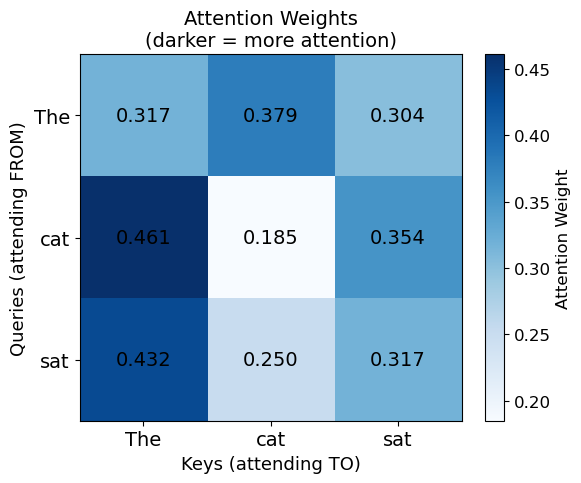

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(attention_weights, cmap='Blues', aspect='auto')

# Labels
ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels(words, fontsize=14)
ax.set_yticklabels(words, fontsize=14)
ax.set_xlabel('Keys (attending TO)', fontsize=13)
ax.set_ylabel('Queries (attending FROM)', fontsize=13)
ax.set_title('Attention Weights\n(darker = more attention)', fontsize=14)

# Add text annotations
for i in range(len(words)):
    for j in range(len(words)):
        color = 'white' if attention_weights[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{attention_weights[i, j]:.3f}',
                ha='center', va='center', fontsize=14, color=color)

plt.colorbar(im, ax=ax, label='Attention Weight')
plt.tight_layout()
plt.show()

## Part 8: Weighted Sum of Values (The Final Output)

The last step: multiply the attention weights by the Value vectors to get a **weighted combination** of information.

Each output word is now a blend of all input words, weighted by how relevant they are.

In [10]:
# Final output = attention_weights × V
output = attention_weights @ V  # (3 × 3) @ (3 × 3) = (3 × 3)

print("Output of attention (weighted sum of values):")
print(f"Shape: {output.shape}\n")

for i, word in enumerate(words):
    print(f"  output for '{word}': {np.round(output[i], 4)}")
    # Show the breakdown
    parts = []
    for j, w2 in enumerate(words):
        parts.append(f"{attention_weights[i, j]:.3f} × V_{w2}")
    print(f"    = {' + '.join(parts)}")
    print()

Output of attention (weighted sum of values):
Shape: (3, 3)

  output for 'The': [-0.2552  0.2769 -0.4668]
    = 0.317 × V_The + 0.379 × V_cat + 0.304 × V_sat

  output for 'cat': [-0.3137  0.2184 -0.5634]
    = 0.461 × V_The + 0.185 × V_cat + 0.354 × V_sat

  output for 'sat': [-0.2917  0.2349 -0.5298]
    = 0.432 × V_The + 0.250 × V_cat + 0.317 × V_sat



## Part 9: The Complete Attention Function

Let's put it all together into one clean function:

```
                        Q × K^T
Attention(Q, K, V) = softmax( ─────── ) × V
                         √d_k
```

In [11]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Compute Scaled Dot-Product Attention.
    
    Args:
        Q: Queries  (num_words × d_k)
        K: Keys     (num_words × d_k)
        V: Values   (num_words × d_v)
        mask: Optional mask to prevent attending to certain positions
    
    Returns:
        output: Weighted sum of values (num_words × d_v)
        weights: Attention weights     (num_words × num_words)
    """
    d_k = Q.shape[-1]
    
    # Step 1: Compute similarity scores
    scores = Q @ K.T  # (num_words × num_words)
    
    # Step 2: Scale
    scores = scores / np.sqrt(d_k)
    
    # Step 3: Apply mask (if provided)
    if mask is not None:
        scores = np.where(mask == 0, -1e9, scores)
    
    # Step 4: Softmax to get weights
    weights = softmax(scores)
    
    # Step 5: Weighted sum of values
    output = weights @ V
    
    return output, weights

# Test it!
output, weights = scaled_dot_product_attention(Q, K, V)
print("Attention output shape:", output.shape)
print("Attention weights shape:", weights.shape)
print("\nAttention weights:")
print(np.round(weights, 4))

Attention output shape: (3, 3)
Attention weights shape: (3, 3)

Attention weights:
[[0.3174 0.379  0.3035]
 [0.4612 0.1848 0.354 ]
 [0.4324 0.2504 0.3171]]


## Part 10: Causal (Decoder) Masking

In decoder models (like GPT), each word can only attend to words that came **before** it. We achieve this with a **causal mask**.

The mask sets "future" attention scores to negative infinity before softmax, making those weights effectively zero.

In [12]:
# Create a causal mask (lower triangular matrix)
seq_len = len(words)
causal_mask = np.tril(np.ones((seq_len, seq_len)))  # Lower triangle of 1s

print("Causal mask (1 = can attend, 0 = cannot attend):")
print(f"{'':>8}", end="")
for word in words:
    print(f"{word:>8}", end="")
print()
for i, word in enumerate(words):
    print(f"{word:>6} |", end="")
    for j in range(len(words)):
        symbol = "  CAN" if causal_mask[i, j] == 1 else "    X"
        print(f"{symbol:>8}", end="")
    print()

print("\n'The' can only see itself")
print("'cat' can see 'The' and itself")
print("'sat' can see everything before it")

Causal mask (1 = can attend, 0 = cannot attend):
             The     cat     sat
   The |     CAN       X       X
   cat |     CAN     CAN       X
   sat |     CAN     CAN     CAN

'The' can only see itself
'cat' can see 'The' and itself
'sat' can see everything before it


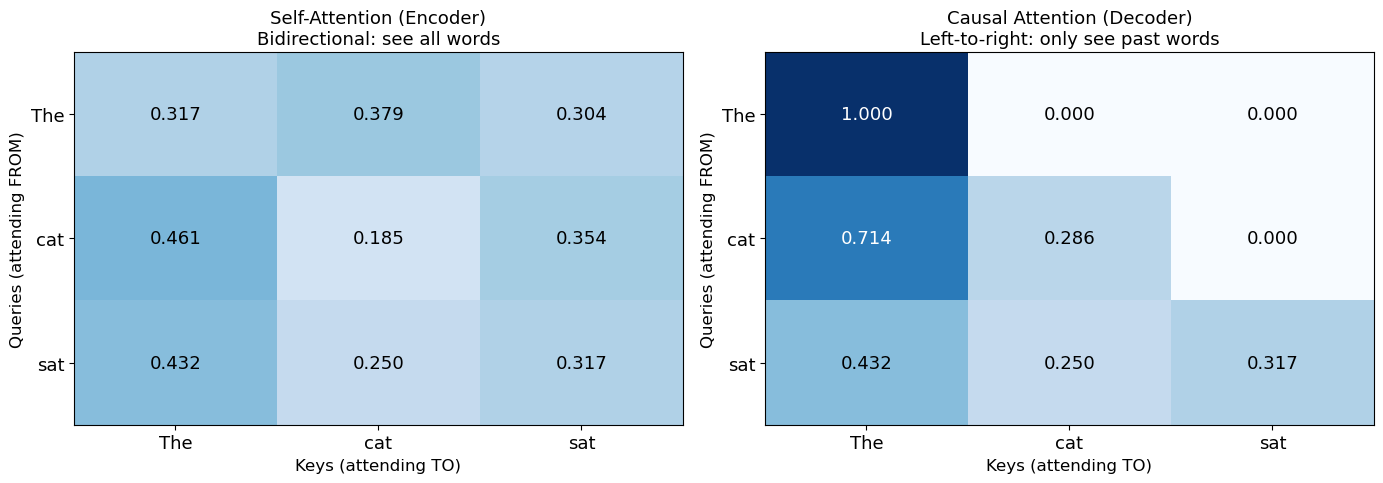

Notice: In causal attention, the upper-right triangle is zeroed out.
Each word can only attend to itself and previous words.


In [13]:
# Apply causal masking
output_masked, weights_masked = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

# Visualize both side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, w, title in [
    (axes[0], weights, 'Self-Attention (Encoder)\nBidirectional: see all words'),
    (axes[1], weights_masked, 'Causal Attention (Decoder)\nLeft-to-right: only see past words')
]:
    im = ax.imshow(w, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(words)))
    ax.set_yticks(range(len(words)))
    ax.set_xticklabels(words, fontsize=13)
    ax.set_yticklabels(words, fontsize=13)
    ax.set_xlabel('Keys (attending TO)', fontsize=12)
    ax.set_ylabel('Queries (attending FROM)', fontsize=12)
    ax.set_title(title, fontsize=13)
    for i in range(len(words)):
        for j in range(len(words)):
            color = 'white' if w[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{w[i, j]:.3f}',
                    ha='center', va='center', fontsize=13, color=color)

plt.tight_layout()
plt.show()
print("Notice: In causal attention, the upper-right triangle is zeroed out.")
print("Each word can only attend to itself and previous words.")

## Part 11: A Longer Example

Let's try a more realistic sentence to see attention in action:

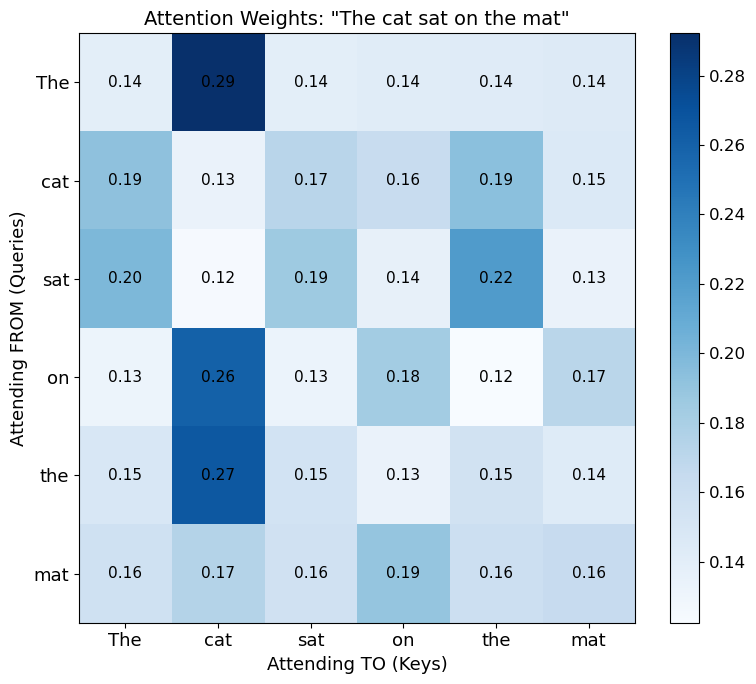

In [14]:
# Longer sentence with more interesting attention patterns
sentence = ["The", "cat", "sat", "on", "the", "mat"]
n_words = len(sentence)
d_model_big = 8
d_k_big = 6

# Random embeddings (in real models these are learned)
np.random.seed(123)
X_big = np.random.randn(n_words, d_model_big) * 0.5

# Make similar words have similar embeddings
# "The" and "the" should be similar
X_big[4] = X_big[0] + np.random.randn(d_model_big) * 0.1
# "cat" and "mat" rhyme and are both nouns
X_big[5] = X_big[1] * 0.3 + np.random.randn(d_model_big) * 0.3

# Random weight matrices
W_Q_big = np.random.randn(d_model_big, d_k_big) * 0.3
W_K_big = np.random.randn(d_model_big, d_k_big) * 0.3
W_V_big = np.random.randn(d_model_big, d_k_big) * 0.3

Q_big = X_big @ W_Q_big
K_big = X_big @ W_K_big
V_big = X_big @ W_V_big

output_big, weights_big = scaled_dot_product_attention(Q_big, K_big, V_big)

# Visualize
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(weights_big, cmap='Blues', aspect='auto')
ax.set_xticks(range(n_words))
ax.set_yticks(range(n_words))
ax.set_xticklabels(sentence, fontsize=13)
ax.set_yticklabels(sentence, fontsize=13)
ax.set_xlabel('Attending TO (Keys)', fontsize=13)
ax.set_ylabel('Attending FROM (Queries)', fontsize=13)
ax.set_title('Attention Weights: "The cat sat on the mat"', fontsize=14)

for i in range(n_words):
    for j in range(n_words):
        color = 'white' if weights_big[i, j] > 0.4 else 'black'
        ax.text(j, i, f'{weights_big[i, j]:.2f}',
                ha='center', va='center', fontsize=11, color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Part 12: Self-Attention vs. Cross-Attention

There are two types of attention:

- **Self-attention**: Q, K, V all come from the **same** sequence (words attending to each other)
- **Cross-attention**: Q comes from one sequence, K and V from another (e.g., translation)

Let's implement both:

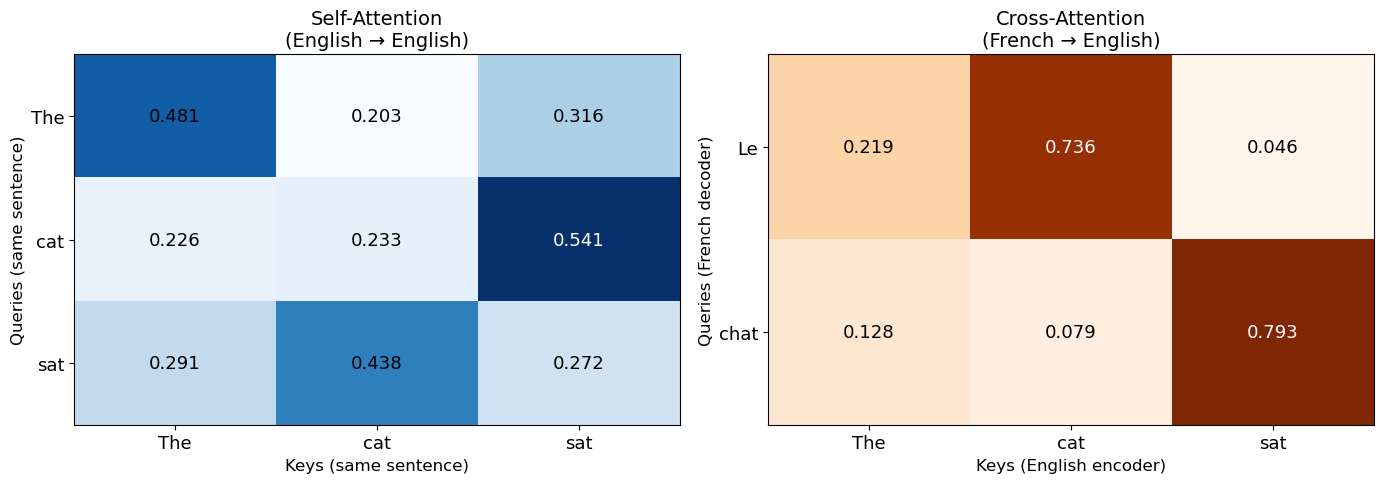

Self-attention: each English word attends to other English words.
Cross-attention: each French word attends to English words for translation context.


In [15]:
# === Self-Attention ===
# All Q, K, V come from the same sentence
english = ["The", "cat", "sat"]
np.random.seed(42)
X_eng = np.random.randn(3, 4)

W_Q_sa = np.random.randn(4, 3) * 0.5
W_K_sa = np.random.randn(4, 3) * 0.5
W_V_sa = np.random.randn(4, 3) * 0.5

Q_self = X_eng @ W_Q_sa  # From English sentence
K_self = X_eng @ W_K_sa  # From English sentence (SAME!)
V_self = X_eng @ W_V_sa  # From English sentence (SAME!)

_, self_attn_weights = scaled_dot_product_attention(Q_self, K_self, V_self)

# === Cross-Attention ===
# Q from French (decoder), K and V from English (encoder)
french = ["Le", "chat"]
X_fr = np.random.randn(2, 4)

W_Q_ca = np.random.randn(4, 3) * 0.5
W_K_ca = np.random.randn(4, 3) * 0.5
W_V_ca = np.random.randn(4, 3) * 0.5

Q_cross = X_fr @ W_Q_ca   # From French (decoder asks questions)
K_cross = X_eng @ W_K_ca  # From English (encoder provides context)
V_cross = X_eng @ W_V_ca  # From English (encoder provides context)

_, cross_attn_weights = scaled_dot_product_attention(Q_cross, K_cross, V_cross)

# Visualize both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Self-attention
im1 = axes[0].imshow(self_attn_weights, cmap='Blues', aspect='auto')
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(3))
axes[0].set_xticklabels(english, fontsize=13)
axes[0].set_yticklabels(english, fontsize=13)
axes[0].set_title('Self-Attention\n(English → English)', fontsize=14)
axes[0].set_xlabel('Keys (same sentence)', fontsize=12)
axes[0].set_ylabel('Queries (same sentence)', fontsize=12)
for i in range(3):
    for j in range(3):
        color = 'white' if self_attn_weights[i, j] > 0.5 else 'black'
        axes[0].text(j, i, f'{self_attn_weights[i, j]:.3f}',
                     ha='center', va='center', fontsize=13, color=color)

# Cross-attention
im2 = axes[1].imshow(cross_attn_weights, cmap='Oranges', aspect='auto')
axes[1].set_xticks(range(3))
axes[1].set_yticks(range(2))
axes[1].set_xticklabels(english, fontsize=13)
axes[1].set_yticklabels(french, fontsize=13)
axes[1].set_title('Cross-Attention\n(French → English)', fontsize=14)
axes[1].set_xlabel('Keys (English encoder)', fontsize=12)
axes[1].set_ylabel('Queries (French decoder)', fontsize=12)
for i in range(2):
    for j in range(3):
        color = 'white' if cross_attn_weights[i, j] > 0.5 else 'black'
        axes[1].text(j, i, f'{cross_attn_weights[i, j]:.3f}',
                     ha='center', va='center', fontsize=13, color=color)

plt.tight_layout()
plt.show()

print("Self-attention: each English word attends to other English words.")
print("Cross-attention: each French word attends to English words for translation context.")

## Summary

In this notebook, we built attention from scratch! Here's what we covered:

| Step | What Happens | Code |
|------|-------------|------|
| 1. Embed | Words → vectors | `X = embeddings[words]` |
| 2. Project | Create Q, K, V | `Q = X @ W_Q` |
| 3. Score | Measure similarity | `scores = Q @ K.T` |
| 4. Scale | Prevent extreme values | `scores / √d_k` |
| 5. Softmax | Scores → weights | `weights = softmax(scores)` |
| 6. Combine | Weighted sum of values | `output = weights @ V` |

### The Complete Formula

```
Attention(Q, K, V) = softmax(Q × K^T / √d_k) × V
```

### Key Takeaways

1. **Attention** lets every word look at every other word
2. **Q, K, V** are different learned projections of the same embeddings
3. **Dot product** measures how well a Query matches a Key
4. **Scaling** prevents softmax from becoming too sharp
5. **Causal masking** prevents looking at future words (used in GPT-like models)
6. **Self-attention** = same-sequence, **Cross-attention** = across sequences

**Next:** [Multi-Head Attention](./02_multi_head_attention.ipynb) — running multiple attention heads in parallel.

## Layer 2: Expert Depth

### Complexity Analysis

| Operation | Time Complexity | Memory |
|-----------|----------------|--------|
| Q, K, V projections | O(n × d_model × d_k) | O(n × d_k) |
| QK^T (attention scores) | O(n² × d_k) | O(n²) per head |
| Softmax | O(n²) | O(n²) |
| Weighted sum (× V) | O(n² × d_v) | O(n × d_v) |
| **Full attention** | **O(n² × d_model)** | **O(n²)** |

The **n²** term is why long contexts are expensive:
- 512 tokens → 262K attention cells per head per layer
- 4096 tokens → 16.8M cells (64× more)
- 128K tokens → 16.4B cells (62,500× more!)

This is what motivated Flash Attention (reorders computation to avoid materializing the full n×n matrix) and sparse attention variants.

### Failure Modes to Know

**1. Attention collapse (uniform weights)**
All words get equal attention weight (~1/n). Happens early in training before W_Q and W_K have learned to create discriminative projections. Loss decreases slowly. Fix: better initialization, layer norm before attention.

**2. Attention spike (single-token saturation)**
After training, all attention collapses to one "sink" token (often "." or [CLS]). The model "parks" irrelevant attention here rather than distributing it. Symptom: one column of the attention matrix is always bright. Usually benign but can limit interpretability.

**3. Causal mask bug (future leakage)**
If you forget to apply the causal mask in a decoder, the model can look at future tokens during training. Loss drops fast and training looks great — but at inference (where you CAN'T look ahead), the model fails catastrophically. Always test with known examples where future tokens are wrong.

**4. Numerical instability**
`np.exp(x)` overflows for x > ~710. Always use the stable form: `exp(x - max(x))`. This doesn't change the softmax output mathematically (the max cancels) but prevents overflow.

### Staff/Principal Interview Q&A

**Q: Why √d_k specifically? Why not just d_k or a learned scalar?**

The choice of √d_k is analytically motivated: it normalizes dot products from variance d_k back to variance 1, assuming unit-variance inputs. Using d_k would over-correct (variance → 1/d_k, attention too uniform). A learned scalar could work but adds a parameter per layer, and in practice the fixed √d_k works well enough. The real test: ablations in the original paper showed performance degraded without scaling, and √d_k was the simplest theoretically justified choice.

**Q: What is Flash Attention and when does it matter?**

Standard attention materializes the full n×n score matrix in GPU HBM (slow off-chip memory). Flash Attention (Dao et al. 2022) tiles the computation: it processes Q in blocks, computing partial softmax results incrementally using the log-sum-exp trick, and accumulates the weighted V sum without ever writing the full matrix to HBM. Result: memory drops from O(n²) to O(n); runtime drops 2–4× for typical sequence lengths because HBM bandwidth is the bottleneck, not FLOPs. Flash Attention is exact (same result as standard), not approximate. It matters at any sequence length > ~512. It's the reason 100K+ context windows became practical.

**Q: Cross-attention: why Q from decoder, K and V from encoder?**

The decoder's job is to decide "what input information do I need to generate the next output token?" This is a question — hence Query. The encoder has already computed rich representations of all input tokens — these are the reference points to search (Keys) and the information to retrieve (Values). Reversing it (Q from encoder, K,V from decoder) would mean the encoder is asking questions about partially-generated decoder output, which changes at every generation step and requires recomputing encoder attention at every step. Current design: encoder runs once, its K and V are cached; decoder Q changes each step but only requires a small computation.

In [16]:
# ============================================================
# COACH — Session End  (do not remove this cell)
# ============================================================
from coach.notebook_widgets import render_session_end
render_session_end(_SESSION)